In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
data = pd.read_csv("/content/online_vs_offline_learning_dataset.csv")
data.head()

,Learning_Mode,Subject,Study_Hours,Retention_Score,Focus_Level,Exam_Score
0,Offline,English,7.7,51,96,70
1,Offline,English,6.2,90,82,81
2,Online,English,1.2,75,66,71
3,Online,Math,6.5,80,64,77
4,Online,English,5.5,95,58,78


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Learning_Mode    1000 non-null   object 
 1   Subject          1000 non-null   object 
 2   Study_Hours      1000 non-null   float64
 3   Retention_Score  1000 non-null   int64  
 4   Focus_Level      1000 non-null   int64  
 5   Exam_Score       1000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 47.0+ KB


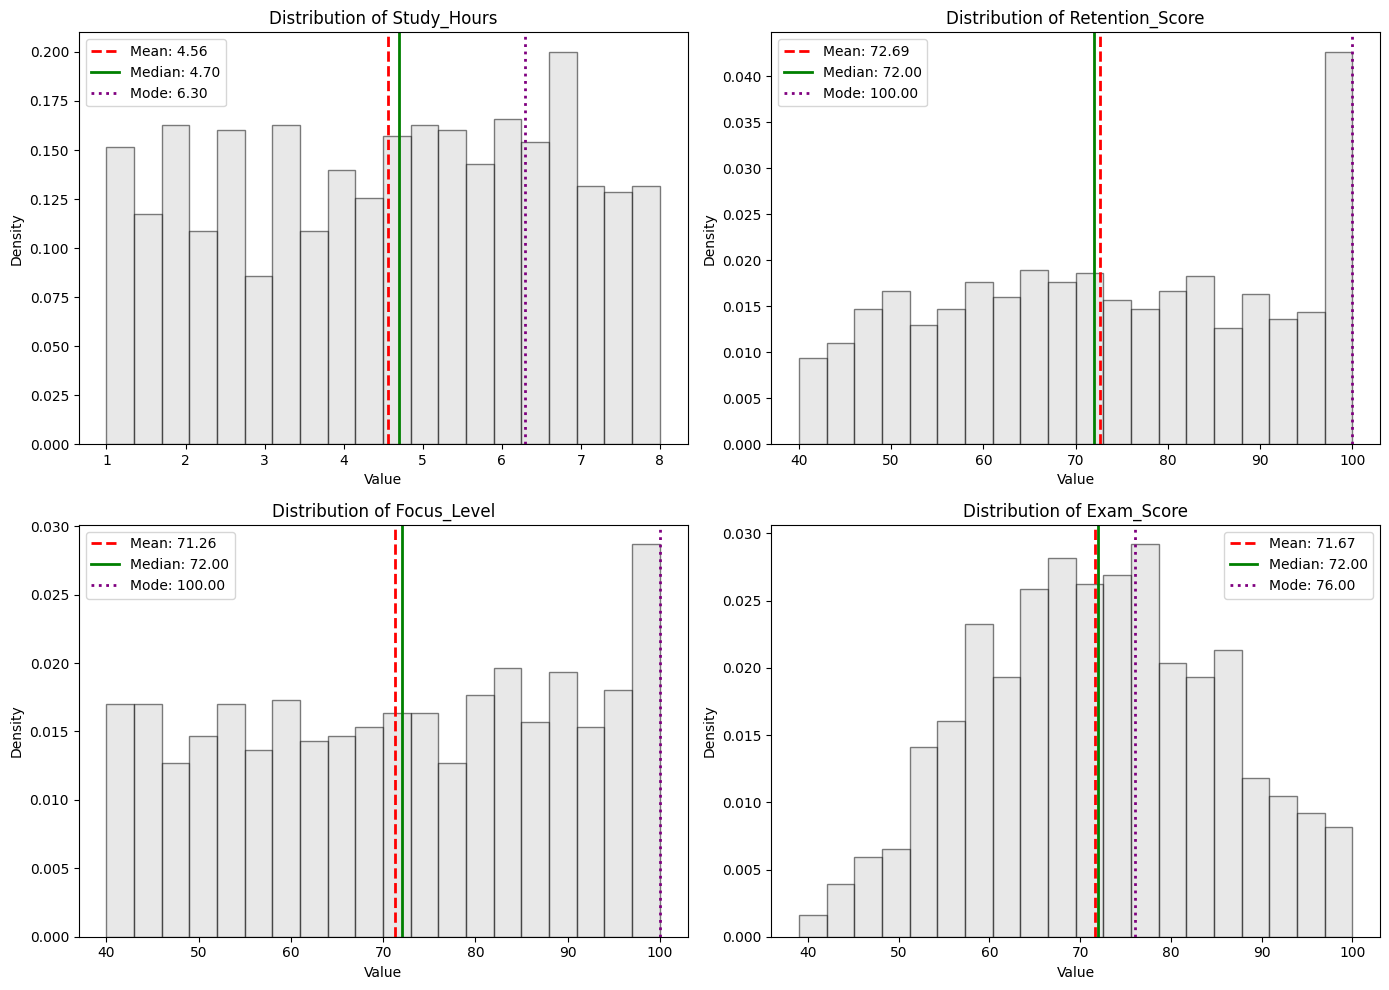

In [30]:
cols_to_plot = data.select_dtypes(include=['int64', 'float64']).columns

num_cols = len(cols_to_plot)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col_name in enumerate(cols_to_plot):
    col_data = data[col_name].dropna()

    mean_val = np.mean(col_data)
    median_val = np.median(col_data)
    mode_val = stats.mode(col_data, keepdims=True).mode[0]

    axes[i].hist(col_data, bins=20, alpha=0.5, color='lightgray', edgecolor='black', density=True)

    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[i].axvline(mode_val, color='purple', linestyle=':', linewidth=2, label=f'Mode: {mode_val:.2f}')

    axes[i].set_title(f'Distribution of {col_name}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()

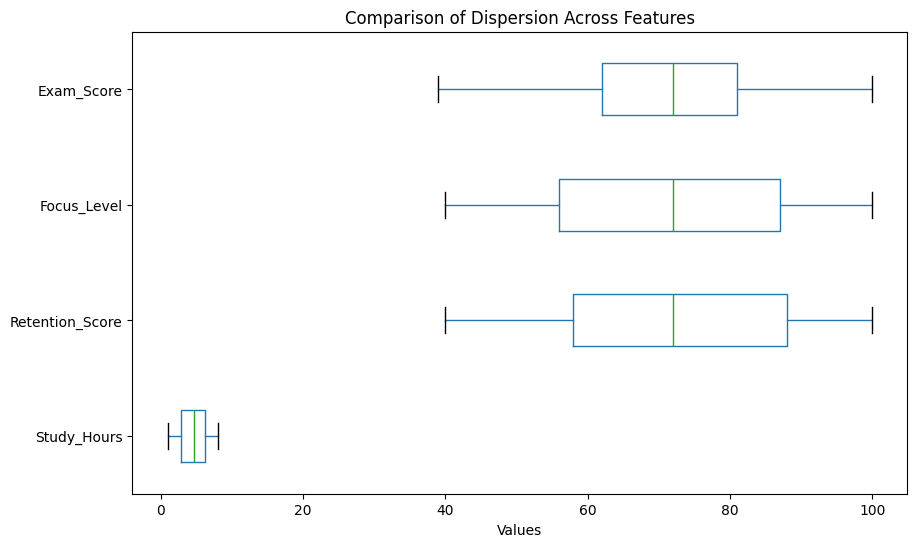

In [32]:
cols = data.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))

data.boxplot(column=list(cols), vert=False, grid=False)

plt.title("Comparison of Dispersion Across Features")
plt.xlabel("Values")
plt.show()

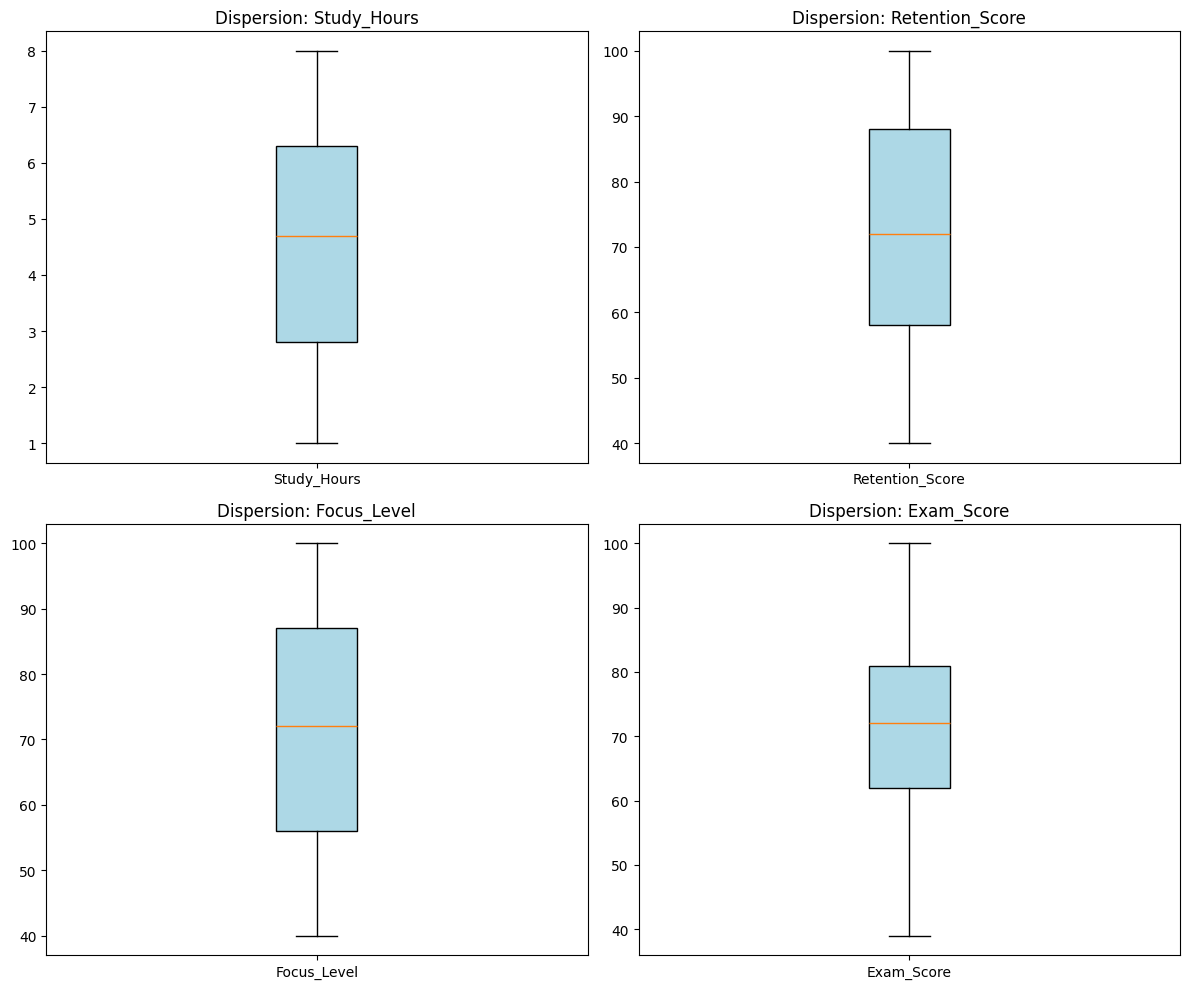

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(data[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))

    axes[i].set_title(f'Dispersion: {col}')
    axes[i].set_xticklabels([col])

plt.tight_layout()
plt.show()